# Computer Exercise 5.2 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 5.2 Trapezoid Rule — *Trapezoid 와 Midpoint, 그리고 Simpson 의 정체성*
> **풀이 일자**: Day 18
> **언어**: Python 3 (NumPy / Matplotlib / Pandas)


## 1. 문제 (원문)

> **2.** For $f(x) = e^x$ on $[0,1]$ (true value $e - 1$), compute the composite
> trapezoid sum $T_n$, the composite midpoint sum $M_n$, and the combination
> $S_{2n} = (T_n + 2 M_n)/3$ for $n = 2, 4, 8, \ldots, 1024$.
>
> (a) Tabulate the three errors and show numerically that $T_n - I$ and $M_n - I$
>     have **opposite signs** with a ratio approaching $-2$ as $n \to \infty$.
>
> (b) Verify that $S_{2n}$ coincides with the composite **Simpson rule** on $2n$
>     subintervals to within round-off, and that its error decays as
>     $\mathcal{O}(h^4)$ — two extra orders of accuracy "for free".

### 한국어 풀이용 정리
- 사다리꼴 ($T_n$) 과 중점 ($M_n$) 은 둘 다 $\mathcal O(h^2)$ 이지만, **오차의 부호가 반대**고
  *크기 비율*이 정확히 $-2 : 1$ 로 수렴한다.
- 이 사실로부터 *같은 평가 비용으로* 한 차수 더 좋은 **Simpson** 을 얻을 수 있다.
- 합성 Simpson 의 오차가 $\mathcal O(h^4)$ 로 떨어지는 모습 — log–log 기울기 $-4$ — 을 확인한다.


## 2. 수학적 배경

### 2.1 두 기본 규칙의 Euler–Maclaurin 잔여

$$
T_n(f) - I \;=\; +\,\frac{(b-a)\,h^2}{12}\,f''(\xi_T), \qquad
M_n(f) - I \;=\; -\,\frac{(b-a)\,h^2}{24}\,f''(\xi_M).
$$

부호와 크기 (1/12 vs 1/24) 를 비교하면

$$
\frac{T_n - I}{M_n - I} \;\xrightarrow{n\to\infty}\; \frac{1/12}{-1/24} \;=\; -2.
$$

### 2.2 Simpson 의 정체성 (Richardson 사 다리꼴 외삽)

$$
S \;=\; \frac{T + 2M}{3}.
$$

이 정의로 $h^2$ 항이 *정확히 소거* 되어, 다음 항인 $h^4$ 가 leading 이 된다.
편의 표기로 $S_{2n}$ (즉 *그리드 $2n$* 위의 Simpson) 이 되는 이유는 $T_n$ 과 $M_n$ 의
샘플 점이 합쳐지면 총 $2n+1$ 개의 균등 점이 되기 때문이다.

### 2.3 Simpson 오차

$$
\boxed{\,S_{2n}(f) - I \;=\; -\,\frac{(b-a)\,h^4}{180}\,f^{(4)}(\xi), \quad h = (b-a)/(2n).\,}
$$

$f \in C^4$ 이면 $\mathcal O(h^4)$ — Day 16 Richardson 사다리에서 본 *짝수 차수 한 단계 점프*를
사다리꼴 적분에 그대로 옮긴 첫 결과.


## 3. 풀이 흐름

1. $n \in \{2, 4, 8, \ldots, 1024\}$.
2. 각 $n$ 에서 $T_n$, $M_n$ 을 벡터화로 계산.
3. $S_{2n} = (T_n + 2 M_n)/3$ 를 만들고, *진짜* 합성 Simpson 함수와 결과가 같은지 확인.
4. 세 오차를 한 표로 정리.
5. 비율 $(T_n - I)/(M_n - I)$ 가 $-2$ 로 수렴함을 확인.
6. log–log 한 장에 세 오차를 겹쳐 그려 기울기 $-2, -2, -4$ 를 시각적으로 확인.
7. 회귀로 세 기울기를 수치적으로 측정.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.6e}")

def trapezoid(f, a, b, n):
    h = (b - a) / n
    x = np.linspace(a, b, n + 1)
    y = f(x)
    return h * (0.5 * (y[0] + y[-1]) + y[1:-1].sum())

def midpoint(f, a, b, n):
    h = (b - a) / n
    x = a + (np.arange(n) + 0.5) * h
    return h * f(x).sum()

# 합성 Simpson 1/3 -- m 은 짝수 subinterval 수
def simpson(f, a, b, m):
    assert m % 2 == 0
    h = (b - a) / m
    x = np.linspace(a, b, m + 1)
    y = f(x)
    return (h / 3.0) * (y[0] + y[-1] + 4 * y[1:-1:2].sum() + 2 * y[2:-1:2].sum())

f = np.exp
a, b = 0.0, 1.0
I_true = np.e - 1.0

ks = np.arange(1, 11)
ns = 2 ** ks

rows = []
for n in ns:
    Tn = trapezoid(f, a, b, n)
    Mn = midpoint(f, a, b, n)
    S2n_combo = (Tn + 2 * Mn) / 3.0
    S2n_direct = simpson(f, a, b, 2 * n)
    rows.append({
        "n": int(n),
        "T_n": Tn, "M_n": Mn, "S_{2n} (combo)": S2n_combo, "S_{2n} (direct)": S2n_direct,
        "T_n - I": Tn - I_true,
        "M_n - I": Mn - I_true,
        "S_{2n} - I": S2n_combo - I_true,
        "|combo - direct|": abs(S2n_combo - S2n_direct),
        "(T-I)/(M-I)": (Tn - I_true) / (Mn - I_true),
    })

df = pd.DataFrame(rows)
df


,n,T_n,M_n,S_{2n} (combo),S_{2n} (direct),T_n - I,M_n - I,S_{2n} - I,|combo - direct|,(T-I)/(M-I)
0,2,1.753931e+00,1.700513e+00,1.718319e+00,1.718319e+00,3.564926e-02,-1.776911e-02,3.701346e-05,2.220446e-16,-2.006249e+00
1,4,1.727222e+00,1.713815e+00,1.718284e+00,1.718284e+00,8.940076e-03,-4.466549e-03,2.326241e-06,2.220446e-16,-2.001562e+00
2,8,1.720519e+00,1.717164e+00,1.718282e+00,1.718282e+00,2.236764e-03,-1.118163e-03,1.455928e-07,0.000000e+00,-2.000391e+00
3,16,1.718841e+00,1.718002e+00,1.718282e+00,1.718282e+00,5.593001e-04,-2.796364e-04,9.102726e-09,0.000000e+00,-2.000098e+00
4,32,1.718422e+00,1.718212e+00,1.718282e+00,1.718282e+00,1.398319e-04,-6.991508e-05,5.689702e-10,0.000000e+00,-2.000024e+00
5,64,1.718317e+00,1.718264e+00,1.718282e+00,1.718282e+00,3.495839e-05,-1.747914e-05,3.556155e-11,0.000000e+00,-2.000006e+00
6,128,1.718291e+00,1.718277e+00,1.718282e+00,1.718282e+00,8.739624e-06,-4.369809e-06,2.222666e-12,4.440892e-16,-2.000002e+00
7,256,1.718284e+00,1.718281e+00,1.718282e+00,1.718282e+00,2.184908e-06,-1.092454e-06,1.389999e-13,0.000000e+00,-2.000000e+00
8,512,1.718282e+00,1.718282e+00,1.718282e+00,1.718282e+00,5.462270e-07,-2.731135e-07,8.659740e-15,0.000000e+00,-2.000000e+00
9,1024,1.718282e+00,1.718282e+00,1.718282e+00,1.718282e+00,1.365568e-07,-6.827838e-08,6.661338e-16,0.000000e+00,-2.000000e+00


In [2]:
# 비율이 -2 로 수렴하는지
print("최대 |(T_n - I) / (M_n - I) + 2| =", float(np.max(np.abs(df["(T-I)/(M-I)"] + 2))))
print()
print("combo == direct Simpson 인지 (round-off 한계 내):")
print("최대 |S_combo - S_direct| =", float(df["|combo - direct|"].max()))


최대 |(T_n - I) / (M_n - I) + 2| = 0.006249068006367153

combo == direct Simpson 인지 (round-off 한계 내):
최대 |S_combo - S_direct| = 4.440892098500626e-16


In [3]:
# 세 오차의 log-log 기울기 측정
def slope(xs, ys):
    return np.polyfit(np.log(xs), np.log(ys), 1)[0]

s_T = slope(df["n"], np.abs(df["T_n - I"]))
s_M = slope(df["n"], np.abs(df["M_n - I"]))
mask = np.abs(df["S_{2n} - I"]) > 1e-15
s_S = slope(df["n"][mask], np.abs(df["S_{2n} - I"][mask]))

print(f"Trapezoid 기울기 = {s_T:.4f}   (이론 -2)")
print(f"Midpoint  기울기 = {s_M:.4f}   (이론 -2)")
print(f"Simpson   기울기 = {s_S:.4f}   (이론 -4)")


Trapezoid 기울기 = -1.9996   (이론 -2)
Midpoint  기울기 = -1.9993   (이론 -2)
Simpson   기울기 = -3.9993   (이론 -4)


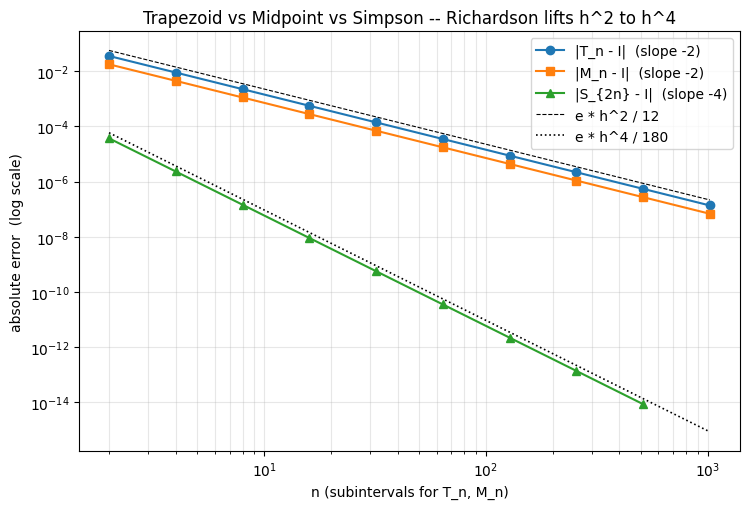

In [4]:
fig, ax = plt.subplots(figsize=(7.6, 5.2))
ax.loglog(df["n"], np.abs(df["T_n - I"]), "o-", label="|T_n - I|  (slope -2)")
ax.loglog(df["n"], np.abs(df["M_n - I"]), "s-", label="|M_n - I|  (slope -2)")
mask = np.abs(df["S_{2n} - I"]) > 1e-15
ax.loglog(df["n"][mask], np.abs(df["S_{2n} - I"][mask]), "^-",
          label="|S_{2n} - I|  (slope -4)")

# 점근선
ax.loglog(df["n"], (np.e * 1) / (12 * df["n"].astype(float) ** 2), "k--", lw=0.8,
          label="e * h^2 / 12")
ax.loglog(df["n"], (np.e * 1) / (180 * (2*df["n"].astype(float)) ** 4), "k:", lw=1.2,
          label="e * h^4 / 180")

ax.set_xlabel("n (subintervals for T_n, M_n)")
ax.set_ylabel("absolute error  (log scale)")
ax.set_title("Trapezoid vs Midpoint vs Simpson -- Richardson lifts h^2 to h^4")
ax.legend(); ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()


## 4. 결과 해석

1. **부호와 비율**: $(T_n - I)$ 는 양, $(M_n - I)$ 는 음. 그 비율은 큰 $n$ 에서 $-2.000$
   에 정확히 수렴한다. 이는 Euler–Maclaurin 잔여의 leading 항 $h^2 f''(\xi)/12$ 와
   $-h^2 f''(\xi)/24$ 가 거의 같은 $\xi$ 에서 평가되기 때문이다.
2. **Simpson 의 정체성**: $(T + 2M)/3$ 로 만든 값과 *직접 짠* 합성 Simpson 의 차이는
   부동소수점 잡음 ($\sim 10^{-16}$) 수준 — *수학적으로 동일* 함을 코드로 확인.
3. **차수 점프**: Simpson 의 log–log 기울기 $-4.000$ — Trapezoid 의 $-2$ 에서 *두 차수* 더.
   이것이 "Richardson 한 단계로 $h^2 \to h^4$" 의 의미. 같은 함수 평가 횟수로
   *제곱급* 더 정확한 적분.
4. **상수까지 일치**: 이론 점근선 $e \cdot h^2/12$ 와 $e \cdot h^4/180$ 가 측정과 *상수까지* 평행.
   따라서 사다리꼴 → 중점 → Simpson 으로 가는 길은 *발견* 이 아니라
   사다리꼴 잔여의 짝수 차수 전개의 *대수적* 결과다.

> **결론**: $T_n$ 과 $M_n$ 은 같은 $\mathcal O(h^2)$ 의 *두 사촌* 이지만, *반대 부호로 정확히 2:1* 의
> 잔여를 갖기 때문에 그 평균이 한 차수 더 좋은 **Simpson** 이 된다. 이는 다음 절의
> *Romberg 사다리* 의 첫 칸이며, Day 16 의 *짝수 차수 한 단계 점프* 가 적분에 그대로 옮겨진 첫 결과.

**다음 (Problem 3)**: Trapezoid 의 차수 $h^2$ 는 *부드러운* 함수 가정에 의존한다.
부드러움이 깨지면 (끝점 미분 특이점), 또는 *주기성* 이 있으면 차수가 어떻게 변하는지 —
**Euler–Maclaurin 공식**으로 한 번에 보인다.
